# Setting up

In [2]:
!pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.5 MB/s eta 0:00:00


# Chat Models

In [3]:
from langchain_groq import ChatGroq
from google.colab import userdata

groq_key = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    api_key=groq_key,
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [4]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg.content

"J'aime la programmation."

## Vision

### Input Image:

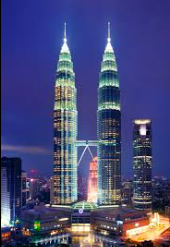

In [5]:
from langchain_groq import ChatGroq
from langchain.messages import HumanMessage

llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", api_key=groq_key)

message = HumanMessage(
    content=[
        {"type": "text", "text": "Describe this image in detail."},
        {
            "type": "image_url",
            "image_url": {"url": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOdkknqik8hCacTe7HkB6CJmocSyYDkkU2FA&s"},
        },
    ]
)

response = llm.invoke([message])
print(response.content)

The image depicts a nighttime scene of the Petronas Twin Towers in Kuala Lumpur, Malaysia. The towers are illuminated with a vibrant display of lights, featuring a predominantly blue and green color scheme that accentuates their architectural details.

**Key Features:**

* **Twin Towers:** The towers are the central focus of the image, standing tall with their distinctive pointed tops and sleek, modern design.
* **Lighting:** The towers are adorned with a mesmerizing light display, showcasing a gradient of blue and green hues that highlight their structural features.
* **Surrounding Buildings:** Several other buildings are visible in the background, although they are less prominent than the twin towers. These structures appear to be shorter and less elaborately lit.
* **Skyline:** The dark blue sky provides a striking contrast to the brightly lit towers, creating a visually appealing atmosphere.
* **Foreground:** In the foreground, there appears to be a large open area or plaza, which 

# Prompts

In [6]:
!pip install -qU langchain-core langchain-community

## Basic Prompting

In [7]:
prompt = """
Answer the user's query based on the context below.
If you cannot answer the question using the
provided information answer with "I don't know".

Context: {context}
"""

In [8]:
from langchain_core.prompts import ChatPromptTemplate

# passing the template to the LangChain model
prompt_template = ChatPromptTemplate.from_messages([
    ("system", prompt),
    ("user", "{query}"),
])

In [9]:
prompt_template.input_variables

['context', 'query']

In [10]:
prompt_template.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='\nAnswer the user\'s query based on the context below.\nIf you cannot answer the question using the\nprovided information answer with "I don\'t know".\n\nContext: {context}\n'), additional_kwargs={}),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['query'], input_types={}, partial_variables={}, template='{query}'), additional_kwargs={})]

## Invoking our LLM with Templates

### Pipelines wuth LCEL

In [11]:
pipeline = (
    {
        "query": lambda x: x["query"],
        "context": lambda x: x["context"]
    }
    | prompt_template
    | llm
)

In [12]:
context = """Aurelio AI is an AI company developing tooling for AI
engineers. Their focus is on language AI with the team having strong
expertise in building AI agents and a strong background in
information retrieval.

The company is behind several open source frameworks, most notably
Semantic Router and Semantic Chunkers. They also have an AI
Platform providing engineers with tooling to help them build with
AI. Finally, the team also provides development services to other
organizations to help them bring their AI tech to market.

Aurelio AI became LangChain Experts in September 2024 after a long
track record of delivering AI solutions built with the LangChain
ecosystem."""

query = "what does Aurelio AI do?"

In [13]:
pipeline.invoke({"query": query, "context": context})

AIMessage(content='Aurelio AI develops tooling for AI engineers, with a focus on language AI. They:\n\n1. Develop open-source frameworks, such as Semantic Router and Semantic Chunkers.\n2. Provide an AI Platform with tooling to help engineers build with AI.\n3. Offer development services to help other organizations bring their AI technology to market.\n\nThey specialize in building AI agents and have a strong background in information retrieval.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 188, 'total_tokens': 272, 'completion_time': 0.190885197, 'completion_tokens_details': None, 'prompt_time': 0.007684156, 'prompt_tokens_details': None, 'queue_time': 0.248774276, 'total_time': 0.198569353}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_4221711889', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3fee-abb2-7083-824d-b9c3f1feb

## Few Shot Prompting

In [14]:
example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{input}"),
    ("ai", "{output}"),
])

In [15]:
examples = [
    {"input": "Here is query #1", "output": "Here is the answer #1"},
    {"input": "Here is query #2", "output": "Here is the answer #2"},
    {"input": "Here is query #3", "output": "Here is the answer #3"},
]

In [16]:
from langchain_core.prompts import FewShotChatMessagePromptTemplate

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)
# here is the formatted prompt
print(few_shot_prompt.format())

Human: Here is query #1
AI: Here is the answer #1
Human: Here is query #2
AI: Here is the answer #2
Human: Here is query #3
AI: Here is the answer #3


In [17]:
new_system_prompt = """
Answer the user's query based on the context below.
If you cannot answer the question using the
provided information answer with "I don't know".

Always answer in markdown format. When doing so please
provide headers, short summaries, follow with bullet
points, then conclude.

Context: {context}
"""

prompt_template.messages[0].prompt.template = new_system_prompt

out = pipeline.invoke({"query": query, "context": context}).content
print(out)

## Overview of Aurelio AI
Aurelio AI is an AI company that develops tooling for AI engineers, focusing on language AI.

## Summary
The company provides various services and tools to support AI engineers and organizations in building and implementing AI solutions.

## Key Activities:
* Develops open-source frameworks, including:
	+ Semantic Router
	+ Semantic Chunkers
* Offers an AI Platform with tooling for AI engineers to build AI solutions
* Provides development services to help organizations bring their AI technology to market
* Specializes in building AI agents and information retrieval

## Expertise
Aurelio AI has a strong background in:
* Language AI
* Building AI agents
* Information retrieval
* LangChain ecosystem (became LangChain Experts in September 2024)


### Another example

In [18]:
examples = [
    {
        "input": "Can you explain gravity?",
        "output": (
            "## Gravity\n\n"
            "Gravity is one of the fundamental forces in the universe.\n\n"
            "### Discovery\n\n"
            "* Gravity was first discovered by Sir Isaac Newton in the late 17th century.\n"
            "* It was said that Newton theorized about gravity after seeing an apple fall from a tree.\n\n"
            "### In General Relativity\n\n"
            "* Gravity is described as the curvature of spacetime.\n"
            "* The more massive an object is, the more it curves spacetime.\n"
            "* This curvature is what causes objects to fall towards each other.\n\n"
            "### Gravitons\n\n"
            "* Gravitons are hypothetical particles that mediate the force of gravity.\n"
            "* They have not yet been detected.\n\n"
            "**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.\n\n"
        )
    },
    {
        "input": "What is the capital of France?",
        "output": (
            "## France\n\n"
            "The capital of France is Paris.\n\n"
            "### Origins\n\n"
            "* The name Paris comes from the Latin word \"Parisini\" which referred to a Celtic people living in the area.\n"
            "* The Romans named the city Lutetia, which means \"the place where the river turns\".\n"
            "* The city was renamed Paris in the 3rd century BC by the Celtic-speaking Parisii tribe.\n\n"
            "**To conclude**, Paris is highly regarded as one of the most beautiful cities in the world and is one of the world's greatest cultural and economic centres.\n\n"
        )
    }
]

In [19]:
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)

### display the prompt now

In [20]:
from IPython.display import display, Markdown

out = few_shot_prompt.format()

display(Markdown(out))

Human: Can you explain gravity?
AI: ## Gravity

Gravity is one of the fundamental forces in the universe.

### Discovery

* Gravity was first discovered by Sir Isaac Newton in the late 17th century.
* It was said that Newton theorized about gravity after seeing an apple fall from a tree.

### In General Relativity

* Gravity is described as the curvature of spacetime.
* The more massive an object is, the more it curves spacetime.
* This curvature is what causes objects to fall towards each other.

### Gravitons

* Gravitons are hypothetical particles that mediate the force of gravity.
* They have not yet been detected.

**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.


Human: What is the capital of France?
AI: ## France

The capital of France is Paris.

### Origins

* The name Paris comes from the Latin word "Parisini" which referred to a Celtic people living in the area.
* The Romans named the city Lutetia, which means "the place where the river turns".
* The city was renamed Paris in the 3rd century BC by the Celtic-speaking Parisii tribe.

**To conclude**, Paris is highly regarded as one of the most beautiful cities in the world and is one of the world's greatest cultural and economic centres.



In [21]:
few_shot_prompt

FewShotChatMessagePromptTemplate(examples=[{'input': 'Can you explain gravity?', 'output': '## Gravity\n\nGravity is one of the fundamental forces in the universe.\n\n### Discovery\n\n* Gravity was first discovered by Sir Isaac Newton in the late 17th century.\n* It was said that Newton theorized about gravity after seeing an apple fall from a tree.\n\n### In General Relativity\n\n* Gravity is described as the curvature of spacetime.\n* The more massive an object is, the more it curves spacetime.\n* This curvature is what causes objects to fall towards each other.\n\n### Gravitons\n\n* Gravitons are hypothetical particles that mediate the force of gravity.\n* They have not yet been detected.\n\n**To conclude**, Gravity is a fascinating topic and has been studied extensively since the time of Newton.\n\n'}, {'input': 'What is the capital of France?', 'output': '## France\n\nThe capital of France is Paris.\n\n### Origins\n\n* The name Paris comes from the Latin word "Parisini" which refe

In [22]:
prompt_template = ChatPromptTemplate.from_messages([
    ("system", new_system_prompt),
    few_shot_prompt,
    ("user", "{query}"),
])

In [23]:
prompt_template.input_variables

['context', 'query']

In [24]:
pipeline = prompt_template | llm
out = pipeline.invoke({"query": query, "context": context}).content
display(Markdown(out))

## Aurelio AI

Aurelio AI is an AI company that develops tooling for AI engineers.

### Focus and Expertise

* The company's focus is on language AI.
* The team has strong expertise in building AI agents and a strong background in information retrieval.

### Products and Services

* Aurelio AI is behind several open-source frameworks, including:
  * Semantic Router
  * Semantic Chunkers
* The company also offers an AI Platform that provides engineers with tooling to help them build with AI.
* Additionally, the team provides development services to other organizations to help them bring their AI technology to market.

### Partnerships

* Aurelio AI became LangChain Experts in September 2024, recognizing their expertise in delivering AI solutions built with the LangChain ecosystem.

**To conclude**, Aurelio AI is a company that specializes in developing tooling and solutions for AI engineers, with a focus on language AI and a strong background in information retrieval.

## COT Prompt

In [25]:
no_cot_system_prompt = """
Be a helpful assistant and answer the user's question.

You MUST answer the question directly without any other
text or explanation.
"""

no_cot_prompt_template = ChatPromptTemplate.from_messages([
    ("system", no_cot_system_prompt),
    ("user", "{query}"),
])

In [26]:
query = (
    "How many keystrokes are needed to type the numbers from 1 to 500?"
)

no_cot_pipeline = no_cot_prompt_template | llm
no_cot_result = no_cot_pipeline.invoke({"query": query}).content
print(no_cot_result)

To type the numbers from 1 to 500, we need to consider the number of keystrokes for single-digit, two-digit, and three-digit numbers.

## Step 1: Calculate keystrokes for single-digit numbers (1-9)
There are 9 single-digit numbers. Each requires 1 keystroke. So, 9 * 1 = 9 keystrokes.

## 2: Calculate keystrokes for two-digit numbers (10-99)
There are 90 two-digit numbers. Each requires 2 keystrokes. So, 90 * 2 = 180 keystrokes.

## 3: Calculate keystrokes for three-digit numbers (100-500)
There are 401 three-digit numbers (from 100 to 500). Each requires 3 keystrokes. So, 401 * 3 = 1203 keystrokes.

## 4: Sum the keystrokes for all numbers
Total keystrokes = 9 (single-digit) + 180 (two-digit) + 1203 (three-digit) = 1392 keystrokes.

The final answer is 1392.


In [27]:
# Define the chain-of-thought prompt template
cot_system_prompt = """
Be a helpful assistant and answer the user's question.

To answer the question, you must:

- List systematically and in precise detail all
  subproblems that need to be solved to answer the
  question.
- Solve each sub problem INDIVIDUALLY and in sequence.
- Finally, use everything you have worked through to
  provide the final answer.
"""

cot_prompt_template = ChatPromptTemplate.from_messages([
    ("system", cot_system_prompt),
    ("user", "{query}"),
])

cot_pipeline = cot_prompt_template | llm

In [28]:
cot_result = cot_pipeline.invoke({"query": query}).content
display(Markdown(cot_result))

## Step 1: Identify the pattern for keystrokes for single-digit numbers
To type the numbers from 1 to 9, we need 9 keystrokes since each number requires one keystroke.

## 2: Identify the pattern for keystrokes for double-digit numbers
For numbers from 10 to 99, there are 90 numbers. Each of these numbers requires 2 keystrokes. So, the total keystrokes for double-digit numbers are 90 * 2 = 180 keystrokes.

## 3: Identify the pattern for keystrokes for triple-digit numbers
For numbers from 100 to 500, there are 401 numbers (since 500 - 100 + 1 = 401). Each of these numbers requires 3 keystrokes. So, the total keystrokes for triple-digit numbers are 401 * 3 = 1203 keystrokes.

## 4: Calculate the total keystrokes needed
To find the total keystrokes needed to type the numbers from 1 to 500, we add the keystrokes for single-digit, double-digit, and triple-digit numbers. Total keystrokes = 9 (for 1-9) + 180 (for 10-99) + 1203 (for 100-500) = 9 + 180 + 1203 = 1392.

The final answer is: $\boxed{1392}$

# LangChain Expression Language (LCEL)

## Traditional LLMChain

In [29]:
from langchain_core.prompts import PromptTemplate

prompt_template = "Give me a small report on {topic}"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_template
)

In [30]:
llm_out = llm.invoke("Hello there")
llm_out

AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 12, 'total_tokens': 35, 'completion_time': 0.052162486, 'completion_tokens_details': None, 'prompt_time': 0.000476308, 'prompt_tokens_details': None, 'queue_time': 0.17466752, 'total_time': 0.052638794}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_4221711889', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3fee-fe23-7e31-b0c3-442ed2943d8d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 23, 'total_tokens': 35})

In [31]:
from langchain_core.output_parsers import StrOutputParser

output_parser = StrOutputParser()

In [32]:
out = output_parser.invoke(llm_out)
out

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

Through the `LLMChain` class we can place each of our components into a linear `chain`.

In [33]:
from langchain.chains import LLMChain

chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)

result = chain.invoke("retrieval augmented generation")
result

ModuleNotFoundError: No module named 'langchain.chains'

It got an error because it's completely depracated, but that's the code to do it before

In [ ]:
from IPython.display import display, Markdown

display(Markdown(result["text"]))

## LCEL

In [34]:
lcel_chain = prompt | llm | output_parser

In [35]:
result = lcel_chain.invoke("retrieval augmented generation")
result

"Here's a small report on Retrieval-Augmented Generation (RAG):\n\n**Introduction**\n\nRetrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) and artificial intelligence (AI) to improve the quality and accuracy of generated text. RAG combines the strengths of two approaches: retrieval-based methods and generation-based methods.\n\n**Retrieval-Based Methods**\n\nRetrieval-based methods involve searching a database or knowledge repository to find relevant information related to a given prompt or query. This approach relies on finding existing text that answers the question or provides relevant information.\n\n**Generation-Based Methods**\n\nGeneration-based methods, on the other hand, use deep learning models to generate text from scratch. These models, such as sequence-to-sequence models or transformers, learn to generate text based on patterns and relationships in the training data.\n\n**Retrieval-Augmented Generation (RAG)**\n\nRAG models aim to 

In [36]:
display(Markdown(result))

Here's a small report on Retrieval-Augmented Generation (RAG):

**Introduction**

Retrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) and artificial intelligence (AI) to improve the quality and accuracy of generated text. RAG combines the strengths of two approaches: retrieval-based methods and generation-based methods.

**Retrieval-Based Methods**

Retrieval-based methods involve searching a database or knowledge repository to find relevant information related to a given prompt or query. This approach relies on finding existing text that answers the question or provides relevant information.

**Generation-Based Methods**

Generation-based methods, on the other hand, use deep learning models to generate text from scratch. These models, such as sequence-to-sequence models or transformers, learn to generate text based on patterns and relationships in the training data.

**Retrieval-Augmented Generation (RAG)**

RAG models aim to leverage the strengths of both retrieval-based and generation-based methods. The approach involves:

1. **Retrieval**: Given a prompt or query, a RAG model retrieves a set of relevant documents or text passages from a knowledge repository or database.
2. **Generation**: The model then uses these retrieved documents as input to a generation model, which produces a response or answer to the original prompt.

**Key Benefits**

The RAG approach offers several benefits:

* **Improved accuracy**: By retrieving relevant documents, RAG models can access a wider range of knowledge and provide more accurate responses.
* **Increased efficiency**: RAG models can reduce the need for extensive training data and computational resources required for traditional generation-based methods.
* **Flexibility**: RAG models can be applied to a wide range of NLP tasks, including question answering, text summarization, and dialogue generation.

**Applications**

RAG has been applied to various NLP tasks, including:

* **Question answering**: RAG models have been used to improve the accuracy of question answering systems, particularly in domains with complex or specialized knowledge.
* **Text summarization**: RAG models can generate summaries that are more informative and accurate by retrieving relevant documents and using them as input.
* **Dialogue generation**: RAG models can be used to generate more coherent and contextually relevant responses in dialogue systems.

**Challenges and Future Directions**

While RAG has shown promising results, there are still several challenges to be addressed, including:

* **Retrieval quality**: The quality of the retrieved documents has a significant impact on the performance of RAG models. Improving retrieval algorithms and knowledge repository construction is an active area of research.
* **Integration with generation models**: Developing effective methods for integrating retrieved documents with generation models is an ongoing research topic.

Overall, Retrieval-Augmented Generation is a promising technique for improving the accuracy and efficiency of NLP systems. Its applications are diverse, and ongoing research aims to address the challenges and limitations of this approach.

## LCEL `RunnableLambda`

The `RunnableLambda` class is LangChain's built-in method for constructing a _runnable_ object from a function. That is, it does the same thing as the custom `Runnable` class we created earlier. Let's try it out with the same functions as before.

In [37]:
def add_five(x):
    return x+5

def sub_five(x):
    return x-5

def mul_five(x):
    return x*5

In [38]:
from langchain_core.runnables import RunnableLambda

add_five_runnable = RunnableLambda(add_five)
sub_five_runnable = RunnableLambda(sub_five)
mul_five_runnable = RunnableLambda(mul_five)

In [39]:
chain = add_five_runnable | sub_five_runnable | mul_five_runnable

In [40]:
chain.invoke(3)

15

Now we want to try something a little more testing, so this time we will generate a report, and we will try and edit that report using this functionallity.

In [41]:
prompt_str = "give me a small report about {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_str
)

In [42]:
chain = prompt | llm | output_parser

In [43]:
result = chain.invoke("AI")
display(Markdown(result))

Here's a small report on AI:

**Introduction**

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has become a rapidly growing field, transforming the way we live, work, and interact with technology.

**Types of AI**

There are two main types of AI:

1. **Narrow or Weak AI**: Designed to perform a specific task, such as facial recognition, language translation, or playing chess. Most AI systems currently in use are narrow AI.
2. **General or Strong AI**: Aims to match human intelligence, with the ability to reason, learn, and apply knowledge across various tasks. General AI is still in the experimental phase.

**Applications of AI**

AI has numerous applications across industries, including:

1. **Virtual Assistants**: Siri, Google Assistant, and Alexa use AI to understand voice commands and respond accordingly.
2. **Image and Speech Recognition**: AI-powered systems can recognize faces, objects, and speech patterns, with applications in security, healthcare, and customer service.
3. **Healthcare**: AI helps diagnose diseases, develop personalized treatment plans, and analyze medical images.
4. **Autonomous Vehicles**: Self-driving cars use AI to navigate roads, detect obstacles, and make decisions in real-time.

**Benefits and Challenges**

Benefits:

* Increased efficiency and productivity
* Improved decision-making and accuracy
* Enhanced customer experience

Challenges:

* Job displacement and skills gap
* Bias and ethics concerns
* Security and data protection risks

**Future of AI**

The future of AI holds much promise, with potential applications in areas like:

1. **Education**: AI-powered adaptive learning systems
2. **Environment**: AI-assisted climate modeling and sustainability efforts
3. **Robotics**: AI-powered robots for manufacturing, healthcare, and services

However, as AI continues to evolve, it's essential to address the challenges and ensure that AI systems are developed and used responsibly.

**Conclusion**

Artificial Intelligence has the potential to revolutionize numerous aspects of our lives, from healthcare and education to transportation and customer service. While there are challenges to be addressed, the benefits of AI are undeniable. As AI continues to advance, it's crucial to prioritize responsible development, deployment, and use of AI systems.

## LCEL `RunnableParallel` and `RunnablePassthrough`

LCEL provides us with various `Runnable` classes that allow us to control the flow of data and execution order through our chains. Two of these are `RunnableParallel` and `RunnablePassthrough`.

* `RunnableParallel` — allows us to run multiple `Runnable` instances in parallel. Acting almost as a Y-fork in the chain.

* `RunnablePassthrough` — allows us to pass through a variable to the next `Runnable` without modification.



> The following code I can't run it because I'm out of API balance :)



In [44]:
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import DocArrayInMemorySearch

embedding = OpenAIEmbeddings()

vecstore_a = DocArrayInMemorySearch.from_texts(
    [
        "half the info is here",
        "DeepSeek-V3 was released in December 2024"
    ],
    embedding=embedding
)
vecstore_b = DocArrayInMemorySearch.from_texts(
    [
        "the other half of the info is here",
        "the DeepSeek-V3 LLM is a mixture of experts model with 671B parameters"
    ],
    embedding=embedding
)

ImportError: cannot import name 'OpenAIEmbeddings' from 'langchain.embeddings' (/usr/local/lib/python3.12/dist-packages/langchain/embeddings/__init__.py)

In [45]:
prompt_str = """Using the context provided, answer the user's question.
Context:
{context_a}
{context_b}
"""

In [ ]:
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(prompt_str),
    HumanMessagePromptTemplate.from_template("{question}")
])

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever_a = vecstore_a.as_retriever()
retriever_b = vecstore_b.as_retriever()

retrieval = RunnableParallel(
    {
        "context_a": retriever_a, "context_b": retriever_b, "question": RunnablePassthrough()
    }
)

The chain we'll be constructing will look something like this:

![](https://github.com/aurelio-labs/langchain-course/blob/main/assets/lcel-flow.png?raw=1)

In [ ]:
chain = retrieval | prompt | llm | output_parser

In [ ]:
result = chain.invoke(
    "what architecture does the model DeepSeek released in december use?"
)
result

With that we've seen how we can use `RunnableParallel` and `RunnablePassthrough` to control the flow of data and execution order through our chains.

---

# Text Splitters

In [4]:
!pip install -qU langchain-community pypdf langchain-text-splitters

In [48]:
from langchain_community.document_loaders import PyPDFLoader

file_path = "/content/Hazem_Waleed_CV.pdf"
loader = PyPDFLoader(file_path)

In [49]:
docs = loader.load()
docs[0]
len(docs)

1

## Recursive splitter

In [50]:
# Split CV into smaller chunks for better retrieval
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
splits = text_splitter.split_documents(docs)
print(f"Pages: {len(docs)}  ->  Chunks: {len(splits)}")


Pages: 1  ->  Chunks: 9


In [51]:
print(splits[0])

page_content='HAZEM W ALEED KHALED
Junior AI Engineer
6 October, Egypt — +20 100 783 1795
hazemwalied2003@gmail.com — linkedin.com/in/hazem-waleed — github.com/hazem-walied
SUMMARY
AI Engineer graduate from Cairo University with a strong foundation in Natural Language Processing (NLP), Large
Language Models (LLMs), Deep Learning, and Data Analytics. Experienced in developing AI-driven solutions and seeking
to leverage strong technical skills in a challenging AI/Data Science role.
EDUCATION' metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-04-12T12:44:40+00:00', 'author': '', 'keywords': '', 'moddate': '2026-04-12T12:44:40+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/Hazem_Waleed_CV.pdf', 'total_pages': 1, 'page': 0, 'page_label': ''}


## Semantic splitter

In [ ]:
# !pip install -qU langchain-experimental openai

from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import OpenAIEmbeddings

# Initialize the embedding model (requires your OPENAI_API_KEY environment variable)
embeddings = OpenAIEmbeddings()

# Set up the semantic splitter
text_splitter = SemanticChunker(embeddings)

# Split your documents
splits = text_splitter.split_documents(docs)
print(f"Pages: {len(docs)}  ->  Chunks: {len(splits)}")

# Vector Stores

In [7]:
!pip install -qU langchain-chroma langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [8]:
!pip install --upgrade chromadb opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp

  Attempting uninstall: opentelemetry-exporter-otlp-proto-http
    Found existing installation: opentelemetry-exporter-otlp-proto-http 1.38.0
    Uninstalling opentelemetry-exporter-otlp-proto-http-1.38.0:
      Successfully uninstalled opentelemetry-exporter-otlp-proto-http-1.38.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.42.0 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.42.0 which is incompatible.


In [52]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [53]:
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="cv_collection",
    embedding_function=embeddings,
    persist_directory="./content",  # Where to save data locally, remove if not necessary
)

In [54]:
import chromadb

client = chromadb.PersistentClient(path="./content")

In [55]:
from uuid import uuid4
from langchain_core.documents import Document


uuids = [str(uuid4()) for _ in range(len(docs))]
vector_store.add_documents(documents=docs, ids=uuids)

['809d7b81-39fe-4dad-a1a9-5f2ffaf175f0']

In [56]:
# Step 3: Build the RAG chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

template = """\n
You are an assistant that answers questions about a candidate CV.
Use ONLY the context below. If the info is not there, say so.

Context:
{context}

Question: {question}
Answer:"""

prompt = ChatPromptTemplate.from_template(template)

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
print("RAG chain ready!")

RAG chain ready!


In [57]:
# Step 4: Ask a sample question
question = "What is the candidate's educational background?"
answer = rag_chain.invoke(question)
print(f"Q: {question}\n")
print(f"A: {answer}")

Q: What is the candidate's educational background?

A: The candidate graduated from the Faculty of Computers & Artificial Intelligence, Cairo University, with a major in Artificial Intelligence, from 2021 to 2025. Their GPA is 3.77, and they were ranked 5th among graduating students.


# Different Similarity Measures

In [58]:
!pip install -qU lark

## Similarity Retrieval

In [59]:
question = "What is the candidate's educational background?"

# Query the store directly to fetch documents along with their distance scores
print("--- Similarity Search with Scores ---")
results_with_scores = vector_store.similarity_search_with_score(question, k=3)

for doc, score in results_with_scores:
    # Note: Chroma uses L2 distance by default (lower score = more similar)
    print(f"[Distance Score: {score:.4f}]")
    print(f"Content: {doc.page_content}\n")

--- Similarity Search with Scores ---
[Distance Score: 1.6132]
Content: HAZEM W ALEED KHALED
Junior AI Engineer
6 October, Egypt — +20 100 783 1795
hazemwalied2003@gmail.com — linkedin.com/in/hazem-waleed — github.com/hazem-walied
SUMMARY
AI Engineer graduate from Cairo University with a strong foundation in Natural Language Processing (NLP), Large
Language Models (LLMs), Deep Learning, and Data Analytics. Experienced in developing AI-driven solutions and seeking
to leverage strong technical skills in a challenging AI/Data Science role.
EDUCATION
Faculty of Computers & Artificial Intelligence, Cairo University 2021 – 2025
Major: Artificial Intelligence — GPA: 3.77
Academic Achievement: Ranked 5 th among graduating students
EXPERIENCE
AI/ML Engineering Internship Jul 2025 – Sep 2025
4SALE International co. (Zamalek, Egypt — Hybrid)
◦Designed and implemented machine learning systems for user analytics and engagement tracking.
◦Conducted data exploration, cleaning, and feature extraction 

## MMR retriever

In [62]:
# Configure MMR retriever
mmr_retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 3,          # Number of final documents to return
        "fetch_k": 7,    # Number of initial documents to fetch and pass to MMR algorithm
        "lambda_mult": 0.5 # 0 = maximum diversity, 1 = pure similarity
    }
)

# Plug it right into your existing chain structure
mmr_rag_chain = (
    {"context": mmr_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("--- MMR RAG Answer ---")
print(mmr_rag_chain.invoke(question))

--- MMR RAG Answer ---
The candidate graduated from the Faculty of Computers & Artificial Intelligence, Cairo University, with a major in Artificial Intelligence, from 2021 to 2025. Their GPA is 3.77, and they were ranked 5th among graduating students.


## Self Query Retriever

In [ ]:
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain.chains.query_constructor.base import AttributeInfo

# 1. Map out the metadata fields present in your 'docs' chunks
# (Adjust names/descriptions to match whatever metadata fields your CV loader created)
metadata_field_info = [
    AttributeInfo(
        name="source",
        description="The file path or origin name of the CV document",
        type="string",
    ),
    AttributeInfo(
        name="page",
        description="The page number from the original CV document",
        type="integer",
    ),
]

document_content_description = "The professional experience, education, and skills listed on a candidate's CV"

# 2. Build the Self-Query Retriever
self_query_retriever = SelfQueryRetriever.from_llm(
    llm=llm, # Uses your existing defined LLM to write the query filters
    vectorstore=vector_store,
    document_contents=document_content_description,
    metadata_field_info=metadata_field_info,
    verbose=True # Displays how the LLM structures the filter in your terminal
)

# 3. Swap it into your RAG chain
self_query_rag_chain = (
    {"context": self_query_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("--- Self-Query RAG Answer ---")
# Try a question that leans into filters, like targeting a specific page or source file
sample_filter_question = "What is the summary of the experience found on page 1?"
print(self_query_rag_chain.invoke(sample_filter_question))